# Extract SCEPTER Outputs

This notebook starts after `05_run_scepter_scenarios.ipynb`. It reads the SCEPTER execution manifest for ESA-cropland/HWSD2/CHIRPS-backed runs, extracts per-run summary files when they exist, joins results back to raster-derived model units, and writes clean result tables for mapping and MRV accounting.

If notebook `05` staged real-data configs but did not execute SCEPTER, this notebook still produces status tables showing which summaries are missing. Once SCEPTER is connected, rerun this notebook to parse completed model outputs.


## Workflow

1. **Load execution manifest** from `data/scepter_runs/outputs/scepter_execution_manifest.csv` and verify notebook 04/05 provenance.
2. **Extract per-run summaries** from `data/scepter_runs/outputs/{run_id}/{run_id}_summary.csv`.
3. **Flag missing results** for staged, failed, or not-yet-executed runs.
4. **Write flat result tables** that retain ESA cropland, HWSD2 soil-map/default, CHIRPS rainfall, and runoff metadata.
5. **Join parsed results back to model-unit geometries** from `data/scepter_runs/inputs/scepter_model_units.gpkg`.
6. **Summarize by scenario** so we can compare baseline and ERW application rates.
7. **Export spatial result layers** for maps and reports.

Expected summary CSV formats are either one-row wide tables, or two-column `metric,value` tables. The parser supports both.


In [1]:
from pathlib import Path
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

def mount_google_drive_if_colab() -> None:
    try:
        from google.colab import drive
    except ModuleNotFoundError:
        return

    drive.mount("/content/drive")


mount_google_drive_if_colab()

COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/erw_spatial_mrv")
COLAB_DATA_ROOT = COLAB_PROJECT_ROOT / "data"
LOCAL_PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()


def has_erw_package(project_root: Path) -> bool:
    return (project_root / "src" / "erw_mrv" / "__init__.py").exists()


def source_root_candidates() -> list[Path]:
    cwd = Path.cwd().resolve()
    candidates = [LOCAL_PROJECT_ROOT, COLAB_PROJECT_ROOT]
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "erw_spatial_mrv"))
    candidates.extend(
        Path(path)
        for path in (
            "/content/erw_spatial_mrv",
            "/content/enhanced_rock_weathering/erw_spatial_mrv",
            "/content/drive/MyDrive/erw_spatial_mrv",
        )
    )
    unique = []
    for candidate in candidates:
        if candidate not in unique:
            unique.append(candidate)
    return unique


def find_source_project_root() -> Path:
    for candidate in source_root_candidates():
        if has_erw_package(candidate):
            return candidate
    checked = chr(10).join(f"- {candidate}" for candidate in source_root_candidates())
    raise ModuleNotFoundError(
        "Could not find src/erw_mrv. The data can live in Google Drive, but "
        "the notebook still needs the project source folder containing src/erw_mrv. "
        "In Colab, upload/sync the full erw_spatial_mrv project or run from a "
        "checkout that includes src/. Checked: "
        f"{checked}"
    )


SOURCE_PROJECT_ROOT = find_source_project_root()
PROJECT_ROOT = COLAB_PROJECT_ROOT if COLAB_DATA_ROOT.exists() else SOURCE_PROJECT_ROOT
DATA_ROOT = COLAB_DATA_ROOT if COLAB_DATA_ROOT.exists() else PROJECT_ROOT / "data"
os.environ["ERW_MRV_DATA_ROOT"] = str(DATA_ROOT)

SRC = SOURCE_PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"SOURCE_PROJECT_ROOT = {SOURCE_PROJECT_ROOT}")
print(f"DATA_ROOT = {DATA_ROOT}")

from erw_mrv.paths import SCEPTER_INPUTS, SCEPTER_OUTPUTS, ensure_dir
from erw_mrv.scepter import (
    extract_scepter_results,
    join_results_to_units,
    load_execution_manifest,
    summarize_scepter_results,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)


PROJECT_ROOT = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv
SOURCE_PROJECT_ROOT = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv
DATA_ROOT = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data


## Configure Paths


In [2]:
MANIFEST_PATH = SCEPTER_OUTPUTS / "scepter_execution_manifest.csv"
MODEL_UNITS_PATH = SCEPTER_INPUTS / "scepter_model_units.gpkg"
RESULTS_DIR = ensure_dir(SCEPTER_OUTPUTS / "extracted")
REQUIRE_REAL_INPUT_METADATA = True

RESULTS_TABLE_PATH = RESULTS_DIR / "scepter_results_long.csv"
SCENARIO_SUMMARY_PATH = RESULTS_DIR / "scepter_scenario_summary.csv"
SPATIAL_RESULTS_PATH = RESULTS_DIR / "scepter_results_by_model_unit.gpkg"

MANIFEST_PATH, MODEL_UNITS_PATH, RESULTS_DIR


(PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/scepter_execution_manifest.csv'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/inputs/scepter_model_units.gpkg'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/extracted'))

## Load Execution Manifest

The manifest tells us which runs were staged or executed, where their output folders live, and which ESA cropland, HWSD2 soil-map/default, CHIRPS rainfall, and runoff inputs were used.


In [3]:
manifest = load_execution_manifest(MANIFEST_PATH)
model_units_metadata = gpd.read_file(MODEL_UNITS_PATH)

required_provenance_columns = [
    "cropland_source",
    "cropland_source_path",
    "soil_map_texture_group",
    "soil_map_source_path",
    "soil_source",
    "rainfall_source",
    "rainfall_months_used",
    "runoff_note",
]
optional_provenance_columns = [
    "cropland_pixels",
    "cropland_pixel_area_m2",
    "cropland_area_note",
    "soil_map_hwsd2_unit_id",
    "soil_map_wrb4",
    "soil_map_fao90",
    "soil_map_clay_pct",
    "soil_map_sand_pct",
    "soil_map_silt_pct",
    "soil_map_join",
    "soil_note",
    "rainfall_source_path",
    "missing_requested_months",
]
provenance_columns = required_provenance_columns + optional_provenance_columns
metadata_source = manifest if all(column in manifest.columns for column in required_provenance_columns) else model_units_metadata
missing_required_columns = [column for column in required_provenance_columns if column not in metadata_source.columns]

if REQUIRE_REAL_INPUT_METADATA and missing_required_columns:
    raise ValueError(
        "Could not verify ESA cropland, HWSD2, and CHIRPS provenance in the manifest or model-unit layer. "
        "Rerun notebook 04, then notebook 05, before extracting outputs. Missing columns: "
        f"{missing_required_columns}"
    )

if REQUIRE_REAL_INPUT_METADATA:
    placeholder_rows = metadata_source.astype(str).apply(lambda col: col.str.contains("placeholder", case=False, na=False)).any(axis=1)
    if placeholder_rows.any():
        raise ValueError(
            f"Found {int(placeholder_rows.sum())} rows using placeholder inputs. "
            "Rerun notebooks 03a, 03b, 04, and 05 with real data available."
        )

    missing_required_values = metadata_source[required_provenance_columns].isna().sum()
    missing_required_values = missing_required_values[missing_required_values > 0]
    if not missing_required_values.empty:
        raise ValueError(
            "Required provenance columns exist but contain missing values: "
            f"{missing_required_values.to_dict()}"
        )

print(f"Runs in manifest: {len(manifest):,}")
print("Cropland source:", metadata_source["cropland_source"].dropna().astype(str).iloc[0])
print("Soil map labels:", sorted(metadata_source["soil_map_texture_group"].dropna().astype(str).unique()))
print("Soil source:", metadata_source["soil_source"].dropna().astype(str).iloc[0])
print("Rainfall source:", metadata_source["rainfall_source"].dropna().astype(str).iloc[0])
print("Rainfall months:", metadata_source["rainfall_months_used"].dropna().astype(str).iloc[0])
manifest.groupby(["scenario_id", "status"]).size().rename("run_count").reset_index()


Runs in manifest: 400
Cropland source: ESA WorldCover cropland mask
Soil map labels: ['Clay', 'Clay loam', 'Loam']
Soil source: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_mdb_HWSD2_LAYERS.csv
Rainfall source: CHIRPS rainfall_chirps_monthly via DE Africa S3
Rainfall months: 2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12


,scenario_id,status,run_count
0,baseline_no_erw,complete,100
1,erw_10t_fine,complete,100
2,erw_20t_fine,complete,100
3,erw_40t_medium,complete,100


## Extract Per-Run Results

For each run, this looks for the expected summary file: `{output_dir}/{run_id}_summary.csv`. Missing summaries now mean SCEPTER has not produced output for that real-data config yet.


In [4]:
results = extract_scepter_results(manifest)
results.to_csv(RESULTS_TABLE_PATH, index=False)

print(f"Parsed runs: {(results['result_status'] == 'parsed').sum():,}")
print(f"Missing summaries: {(results['result_status'] == 'missing_summary').sum():,}")
preview_columns = [
    "run_id",
    "scenario_id",
    "execution_status",
    "result_status",
    "cropland_source",
    "soil_map_texture_group",
    "rainfall_months_used",
    "summary_path",
]
results[[column for column in preview_columns if column in results.columns]].head(20)


Parsed runs: 400
Missing summaries: 0


,run_id,scenario_id,execution_status,result_status,cropland_source,soil_map_texture_group,rainfall_months_used,summary_path
0,mu_00001__baseline_no_erw,baseline_no_erw,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00001__baseline_no_erw/mu_00001__baseline_no_er...
1,mu_00001__erw_10t_fine,erw_10t_fine,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00001__erw_10t_fine/mu_00001__erw_10t_fine_summ...
2,mu_00001__erw_20t_fine,erw_20t_fine,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00001__erw_20t_fine/mu_00001__erw_20t_fine_summ...
3,mu_00001__erw_40t_medium,erw_40t_medium,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00001__erw_40t_medium/mu_00001__erw_40t_medium_...
4,mu_00002__baseline_no_erw,baseline_no_erw,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00002__baseline_no_erw/mu_00002__baseline_no_er...
5,mu_00002__erw_10t_fine,erw_10t_fine,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00002__erw_10t_fine/mu_00002__erw_10t_fine_summ...
6,mu_00002__erw_20t_fine,erw_20t_fine,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00002__erw_20t_fine/mu_00002__erw_20t_fine_summ...
7,mu_00002__erw_40t_medium,erw_40t_medium,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00002__erw_40t_medium/mu_00002__erw_40t_medium_...
8,mu_00003__baseline_no_erw,baseline_no_erw,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00003__baseline_no_erw/mu_00003__baseline_no_er...
9,mu_00003__erw_10t_fine,erw_10t_fine,complete,parsed,ESA WorldCover cropland mask,Loam,"2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12",/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/mu_00003__erw_10t_fine/mu_00003__erw_10t_fine_summ...


## Result Status QA

If all rows are `missing_summary`, notebook `05` staged ESA-cropland/HWSD2/CHIRPS configs but SCEPTER has not produced summary files yet. Check `RUN_EXTERNAL_SCEPTER`, the command template, and the per-run output folders.


In [5]:
status_table = results.groupby(["scenario_id", "execution_status", "result_status"]).size().rename("run_count").reset_index()
provenance_status = (
    results[[column for column in required_provenance_columns if column in results.columns]]
    .drop_duplicates()
    .reset_index(drop=True)
)
status_table, provenance_status


(       scenario_id execution_status result_status  run_count
 0  baseline_no_erw         complete        parsed        100
 1     erw_10t_fine         complete        parsed        100
 2     erw_20t_fine         complete        parsed        100
 3   erw_40t_medium         complete        parsed        100,
                 cropland_source  \
 0  ESA WorldCover cropland mask   
 1  ESA WorldCover cropland mask   
 2  ESA WorldCover cropland mask   
 
                                                                                                                       cropland_source_path  \
 0  /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_cdr_ugagric/data/processed/landuse_landcover/ug_agric_21landuse.tif   
 1  /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_cdr_ugagric/data/processed/landuse_landcover/ug_agric_21landuse.tif   
 2  /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_cdr_ugagric/data/processed/landuse_landcov

## Scenario Summary

When numeric metrics are parsed from SCEPTER summaries, this table aggregates them by scenario. Until SCEPTER output files exist, it reports parsed run counts only.


In [6]:
scenario_summary = summarize_scepter_results(results)
scenario_summary.to_csv(SCENARIO_SUMMARY_PATH, index=False)
scenario_summary


/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/src/erw_mrv/scepter.py:603: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  grouped = results.groupby("scenario_id")[metric_columns].agg(["count", "mean", "sum"]).reset_index()


,scenario_id,cropland_pixels_count,cropland_pixels_mean,cropland_pixels_sum,cropland_pixel_area_m2_count,cropland_pixel_area_m2_mean,cropland_pixel_area_m2_sum,soil_map_hwsd2_unit_id_count,soil_map_hwsd2_unit_id_mean,soil_map_hwsd2_unit_id_sum,soil_map_clay_pct_count,soil_map_clay_pct_mean,soil_map_clay_pct_sum,soil_map_sand_pct_count,soil_map_sand_pct_mean,soil_map_sand_pct_sum,soil_map_silt_pct_count,soil_map_silt_pct_mean,soil_map_silt_pct_sum,ttot_years_count,ttot_years_mean,ttot_years_sum,fdust_g_m2_yr_count,fdust_g_m2_yr_mean,fdust_g_m2_yr_sum,taudust_years_count,taudust_years_mean,taudust_years_sum,q_m_yr_count,q_m_yr_mean,q_m_yr_sum,porosity_count,porosity_mean,porosity_sum,particle_radius_m_count,particle_radius_m_mean,particle_radius_m_sum,scepter_final_int_DIC_time_count,scepter_final_int_DIC_time_mean,scepter_final_int_DIC_time_sum,scepter_final_int_DIC_tflx_count,scepter_final_int_DIC_tflx_mean,scepter_final_int_DIC_tflx_sum,scepter_final_int_DIC_adv_count,scepter_final_int_DIC_adv_mean,scepter_final_int_DIC_adv_sum,scepter_final_int_DIC_dif_count,scepter_final_int_DIC_dif_mean,scepter_final_int_DIC_dif_sum,scepter_final_int_DIC_rain_count,scepter_final_int_DIC_rain_mean,scepter_final_int_DIC_rain_sum,scepter_final_int_DIC_inrt_count,scepter_final_int_DIC_inrt_mean,scepter_final_int_DIC_inrt_sum,scepter_final_int_DIC_g2_count,scepter_final_int_DIC_g2_mean,scepter_final_int_DIC_g2_sum,scepter_final_int_DIC_res_count,scepter_final_int_DIC_res_mean,...,scepter_final_int_ALK_cao_count,scepter_final_int_ALK_cao_mean,scepter_final_int_ALK_cao_sum,scepter_final_int_ALK_mgo_count,scepter_final_int_ALK_mgo_mean,scepter_final_int_ALK_mgo_sum,scepter_final_int_ALK_na2o_count,scepter_final_int_ALK_na2o_mean,scepter_final_int_ALK_na2o_sum,scepter_final_int_ALK_k2o_count,scepter_final_int_ALK_k2o_mean,scepter_final_int_ALK_k2o_sum,scepter_final_int_hco3_cao_count,scepter_final_int_hco3_cao_mean,scepter_final_int_hco3_cao_sum,scepter_final_int_hco3_mgo_count,scepter_final_int_hco3_mgo_mean,scepter_final_int_hco3_mgo_sum,scepter_final_int_hco3_na2o_count,scepter_final_int_hco3_na2o_mean,scepter_final_int_hco3_na2o_sum,scepter_final_int_hco3_k2o_count,scepter_final_int_hco3_k2o_mean,scepter_final_int_hco3_k2o_sum,scepter_final_int_co3_cao_count,scepter_final_int_co3_cao_mean,scepter_final_int_co3_cao_sum,scepter_final_int_co3_mgo_count,scepter_final_int_co3_mgo_mean,scepter_final_int_co3_mgo_sum,scepter_final_int_co3_na2o_count,scepter_final_int_co3_na2o_mean,scepter_final_int_co3_na2o_sum,scepter_final_int_co3_k2o_count,scepter_final_int_co3_k2o_mean,scepter_final_int_co3_k2o_sum,scepter_final_int_co2aq_cao_count,scepter_final_int_co2aq_cao_mean,scepter_final_int_co2aq_cao_sum,scepter_final_int_co2aq_mgo_count,scepter_final_int_co2aq_mgo_mean,scepter_final_int_co2aq_mgo_sum,scepter_final_int_co2aq_na2o_count,scepter_final_int_co2aq_na2o_mean,scepter_final_int_co2aq_na2o_sum,scepter_final_int_co2aq_k2o_count,scepter_final_int_co2aq_k2o_mean,scepter_final_int_co2aq_k2o_sum,scepter_final_int_co2g_cao_count,scepter_final_int_co2g_cao_mean,scepter_final_int_co2g_cao_sum,scepter_final_int_co2g_mgo_count,scepter_final_int_co2g_mgo_mean,scepter_final_int_co2g_mgo_sum,scepter_final_int_co2g_na2o_count,scepter_final_int_co2g_na2o_mean,scepter_final_int_co2g_na2o_sum,scepter_final_int_co2g_k2o_count,scepter_final_int_co2g_k2o_mean,scepter_final_int_co2g_k2o_sum
0,baseline_no_erw,100,90763.12,9076312,100,100.0,10000.0,100,27485.19,2748519,100,24.79,2479,100,47.49,4749,100,27.72,2772,100,0.000001,0.0001,100,0.0,0.0,100,0.0,0.0,100,0.283063,28.306305,100,0.509434,50.943396,100,0.000025,0.0025,100,0.000001,0.0001,100,-0.000097,-0.009699,100,-1.827795e-10,-1.827795e-08,100,1.098477e-25,1.098477e-23,100,0.0,0.0,100,0.0,0.0,100,0.0,0.0,100,0.000005,...,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.0,0,NaN,0.

## Join Results Back To Model Units

This creates a spatial layer with one feature per model-unit/scenario result row. It is the bridge from process-model output back to the ESA cropland raster-block geometries prepared in notebook `04`.


In [7]:
spatial_results = join_results_to_units(results, MODEL_UNITS_PATH)
spatial_results.to_file(SPATIAL_RESULTS_PATH, layer="scepter_results", driver="GPKG")

print(f"Spatial result rows: {len(spatial_results):,}")
print("Spatial columns carrying provenance:", [column for column in required_provenance_columns if column in spatial_results.columns])
SPATIAL_RESULTS_PATH


Spatial result rows: 400
Spatial columns carrying provenance: ['cropland_source', 'cropland_source_path', 'soil_map_texture_group', 'soil_map_source_path', 'soil_source', 'rainfall_source', 'rainfall_months_used', 'runoff_note']


PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/scepter_runs/outputs/extracted/scepter_results_by_model_unit.gpkg')

## Quick Map Preview

This preview shows the model units that have result rows. Once CO2 removal metrics are parsed, change `MAP_COLUMN` to that metric.


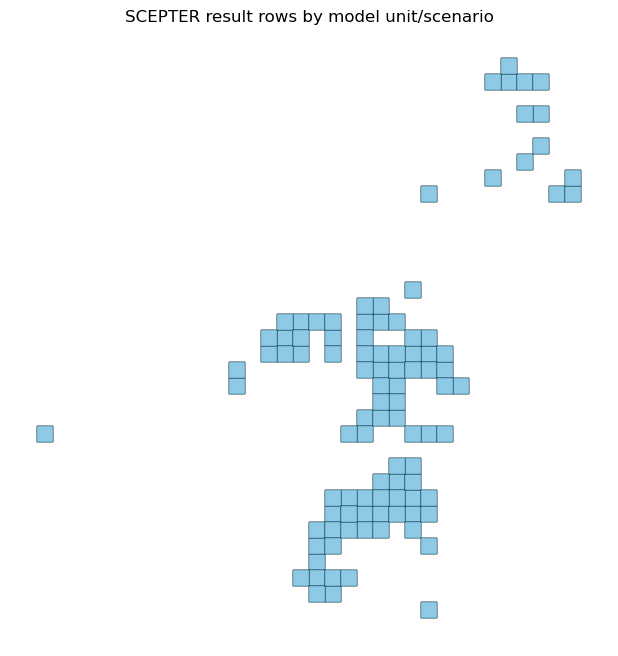

In [8]:
MAP_COLUMN = None
candidate_columns = [
    "co2_removal_t",
    "co2_removal_t_ha",
    "cumulative_co2_removal_t",
    "alkalinity_mol_ha",
]
for column in candidate_columns:
    if column in spatial_results.columns:
        MAP_COLUMN = column
        break

fig, ax = plt.subplots(figsize=(10, 8))
if MAP_COLUMN:
    spatial_results.plot(column=MAP_COLUMN, ax=ax, legend=True, cmap="viridis", linewidth=0.1, edgecolor="black")
    ax.set_title(f"SCEPTER results: {MAP_COLUMN}")
else:
    spatial_results.plot(ax=ax, color="#8ecae6", edgecolor="#023047", linewidth=0.2)
    ax.set_title("SCEPTER result rows by model unit/scenario")
ax.set_axis_off()
plt.show()


## Baseline Comparison Placeholder

The main MRV quantity will be **additional CO2 removal**, calculated as each ERW scenario minus the `baseline_no_erw` result for the same model unit. This cell prepares that comparison when a CO2 metric appears in parsed SCEPTER outputs.


In [9]:
CO2_METRIC_CANDIDATES = [
    "co2_removal_t",
    "cumulative_co2_removal_t",
    "co2_removed_t",
    "net_co2_removal_t",
    "dic_flux_co2_equivalent_t",
]
CARBON_METRIC_CANDIDATES = [
    "carbon_retained_t",
    "carbon_storage_t",
    "soil_carbon_retained_t",
    "dic_flux_carbon_equivalent_t",
]

co2_metric = next((column for column in CO2_METRIC_CANDIDATES if column in results.columns), None)
carbon_metric = next((column for column in CARBON_METRIC_CANDIDATES if column in results.columns), None)

if co2_metric is None:
    additionality = pd.DataFrame(
        columns=[
            "model_unit_id",
            "scenario_id",
            "baseline_co2_t",
            "scenario_co2_t",
            "additional_co2_t",
            "baseline_carbon_t",
            "scenario_carbon_t",
            "additional_carbon_t",
            "co2_metric",
            "carbon_metric",
        ]
    )
    print("No CO2-equivalent metric found yet. Available numeric metrics are:")
    print(results.select_dtypes(include="number").columns.tolist())
else:
    baseline_columns = ["model_unit_id", co2_metric]
    scenario_columns = ["model_unit_id", "scenario_id", co2_metric]
    rename_baseline = {co2_metric: "baseline_co2_t"}
    rename_scenario = {co2_metric: "scenario_co2_t"}

    if carbon_metric:
        baseline_columns.append(carbon_metric)
        scenario_columns.append(carbon_metric)
        rename_baseline[carbon_metric] = "baseline_carbon_t"
        rename_scenario[carbon_metric] = "scenario_carbon_t"

    baseline = results[results["scenario_id"] == "baseline_no_erw"][baseline_columns].rename(columns=rename_baseline)
    scenarios = results[results["scenario_id"] != "baseline_no_erw"][scenario_columns].rename(columns=rename_scenario)
    additionality = scenarios.merge(baseline, on="model_unit_id", how="left")
    additionality["additional_co2_t"] = additionality["scenario_co2_t"] - additionality["baseline_co2_t"]
    additionality["co2_metric"] = co2_metric

    if carbon_metric:
        additionality["additional_carbon_t"] = additionality["scenario_carbon_t"] - additionality["baseline_carbon_t"]
        additionality["carbon_metric"] = carbon_metric
    else:
        additionality["baseline_carbon_t"] = pd.NA
        additionality["scenario_carbon_t"] = pd.NA
        additionality["additional_carbon_t"] = pd.NA
        additionality["carbon_metric"] = pd.NA

additionality_path = RESULTS_DIR / "scepter_additionality.csv"
additionality.to_csv(additionality_path, index=False)
additionality.head(), additionality_path


(  model_unit_id     scenario_id  scenario_co2_t  scenario_carbon_t  \
 0      mu_00001    erw_10t_fine       -0.059172          -0.016149   
 1      mu_00001    erw_20t_fine       -0.059172          -0.016149   
 2      mu_00001  erw_40t_medium       -0.059172          -0.016149   
 3      mu_00002    erw_10t_fine       -0.056293          -0.015363   
 4      mu_00002    erw_20t_fine       -0.056293          -0.015363   
 
    baseline_co2_t  baseline_carbon_t  additional_co2_t  \
 0       -0.059172          -0.016149     -5.025960e-11   
 1       -0.059172          -0.016149     -5.025960e-11   
 2       -0.059172          -0.016149     -5.025960e-11   
 3       -0.056293          -0.015363     -4.781470e-11   
 4       -0.056293          -0.015363     -4.781470e-11   
 
                   co2_metric  additional_carbon_t  \
 0  dic_flux_co2_equivalent_t        -1.371680e-11   
 1  dic_flux_co2_equivalent_t        -1.371680e-11   
 2  dic_flux_co2_equivalent_t        -1.371680e-11   


## Outputs From This Notebook

This notebook writes extracted SCEPTER outputs under `data/scepter_runs/outputs/extracted/`:

- `scepter_results_long.csv`: one row per run with execution status, ESA cropland provenance, HWSD2 soil-map/default provenance, CHIRPS rainfall provenance, runoff assumptions, and parsed metrics when available.
- `scepter_scenario_summary.csv`: scenario-level summary statistics for parsed numeric metrics.
- `scepter_results_by_model_unit.gpkg`: spatial model-unit/scenario result layer for mapping.
- `scepter_additionality.csv`: ERW scenario minus baseline CO2 removal, written once CO2 metrics are present.

The next workflow step is spatial reporting and uncertainty: map the result layers, summarize removal by AOI/district/scenario, and then vary uncertain assumptions such as runoff fraction, particle size, application rate, and soil chemistry.
